라이브러리 불러오기

In [1]:
# =====================
# Scikit-learn models
# =====================
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from sklearn.neural_network import MLPRegressor

# =====================
# Model selection & metrics
# =====================
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectKBest, chi2, f_regression
from sklearn.preprocessing import StandardScaler

# =====================
# Keras (TensorFlow backend, 현대 표준)
# =====================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import SGD
from scikeras.wrappers import KerasRegressor

# =====================
# Time series (현대 ARIMA)
# =====================
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

# =====================
# Data & visualization
# =====================
import numpy as np
import pandas as pd
import pandas_datareader.data as web
from matplotlib import pyplot
from pandas.plotting import scatter_matrix
import seaborn as sns


In [2]:
def build_model():
    model = Sequential()
    model.add(Dense(32, activation="relu", input_shape=(X_train.shape[1],)))
    model.add(Dense(1))
    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model

model = KerasRegressor(
    model=build_model,
    epochs=50,
    batch_size=32,
    verbose=0
)

# **데이터 불러오기**

In [3]:
import pandas_datareader.data as web

stk_tickers = ['MSFT', 'IBM', 'GOOGL']
ccy_tickers = ['DEXJPUS', 'DEXUSUK']
idx_tickers = ['SP500', 'DJIA', 'VIXCLS']

# =====================
# Stock data (Yahoo → Stooq)
# =====================
stk_data = web.DataReader(
    stk_tickers,
    'stooq',
    start="2020-01-01"
)

# =====================
# Currency data (FRED 그대로)
# =====================
ccy_data = web.DataReader(
    ccy_tickers,
    'fred',
    start="2020-01-01"
)

# =====================
# Index data (FRED 그대로)
# =====================
idx_data = web.DataReader(
    idx_tickers,
    'fred',
    start="2020-01-01"
)


**시계열을 지도 회귀 기반 모델 프레임워크로 재구성**

In [4]:
return_period = 5
idx = pd.IndexSlice

# =====================
# Y: MSFT 미래 수익률
# =====================
msft_close = stk_data.xs(
    'MSFT',
    level='Symbols',
    axis=1
)['Close']

Y = np.log(msft_close).diff(return_period).shift(-return_period)
Y.name = 'MSFT_pred'

# =====================
# X1: GOOGL, IBM
# =====================
X1 = np.log(
    stk_data.loc[:, idx['Close', ['GOOGL', 'IBM']]]
).diff(return_period)

X1.columns = X1.columns.droplevel(0)

# =====================
# X2: 환율
# =====================
X2 = np.log(ccy_data).diff(return_period)

# =====================
# X3: 지수
# =====================
X3 = np.log(idx_data).diff(return_period)

# =====================
# X4: MSFT 다중 시차
# =====================
X4 = pd.concat(
    [
        np.log(msft_close).diff(i)
        for i in [return_period, return_period*3, return_period*6, return_period*12]
    ],
    axis=1
)

X4.columns = ['MSFT_DT', 'MSFT_3DT', 'MSFT_6DT', 'MSFT_12DT']

X = pd.concat([X1, X2, X3, X4], axis=1)
dataset = pd.concat([Y, X], axis=1).dropna().iloc[::return_period]

Y = dataset['MSFT_pred']
X = dataset.drop(columns='MSFT_pred')



# **EDA**

**기술 통계**

In [5]:
dataset.head()

,MSFT_pred,GOOGL,IBM,DEXJPUS,DEXUSUK,SP500,DJIA,VIXCLS,MSFT_DT,MSFT_3DT,MSFT_6DT,MSFT_12DT
2020-01-09,-0.009169,-0.021166,-0.008819,0.009546,-0.004504,0.005159,0.003047,0.005598,-0.024883,-0.049058,-0.055693,-0.022117
2020-01-16,-0.024883,-0.010981,-0.018704,0.006283,0.000535,0.012777,0.011698,-0.017700,0.006907,-0.101313,-0.041823,-0.047065
2020-01-24,0.006907,0.023037,-0.022227,-0.007746,0.003218,-0.010309,-0.012286,0.185073,-0.031082,-0.116239,0.088531,-0.019555
2020-02-03,-0.071973,-0.017426,-0.064739,-0.003310,-0.003684,0.001630,-0.004777,-0.014365,-0.078909,0.034132,0.170973,-0.020132
2020-02-10,-0.078909,-0.007118,0.021707,0.010808,-0.006712,0.031261,0.030414,-0.177990,0.007926,0.134593,0.238018,0.030489


**데이터 시각화**

<Axes: title={'center': 'Correlation Matrix'}>

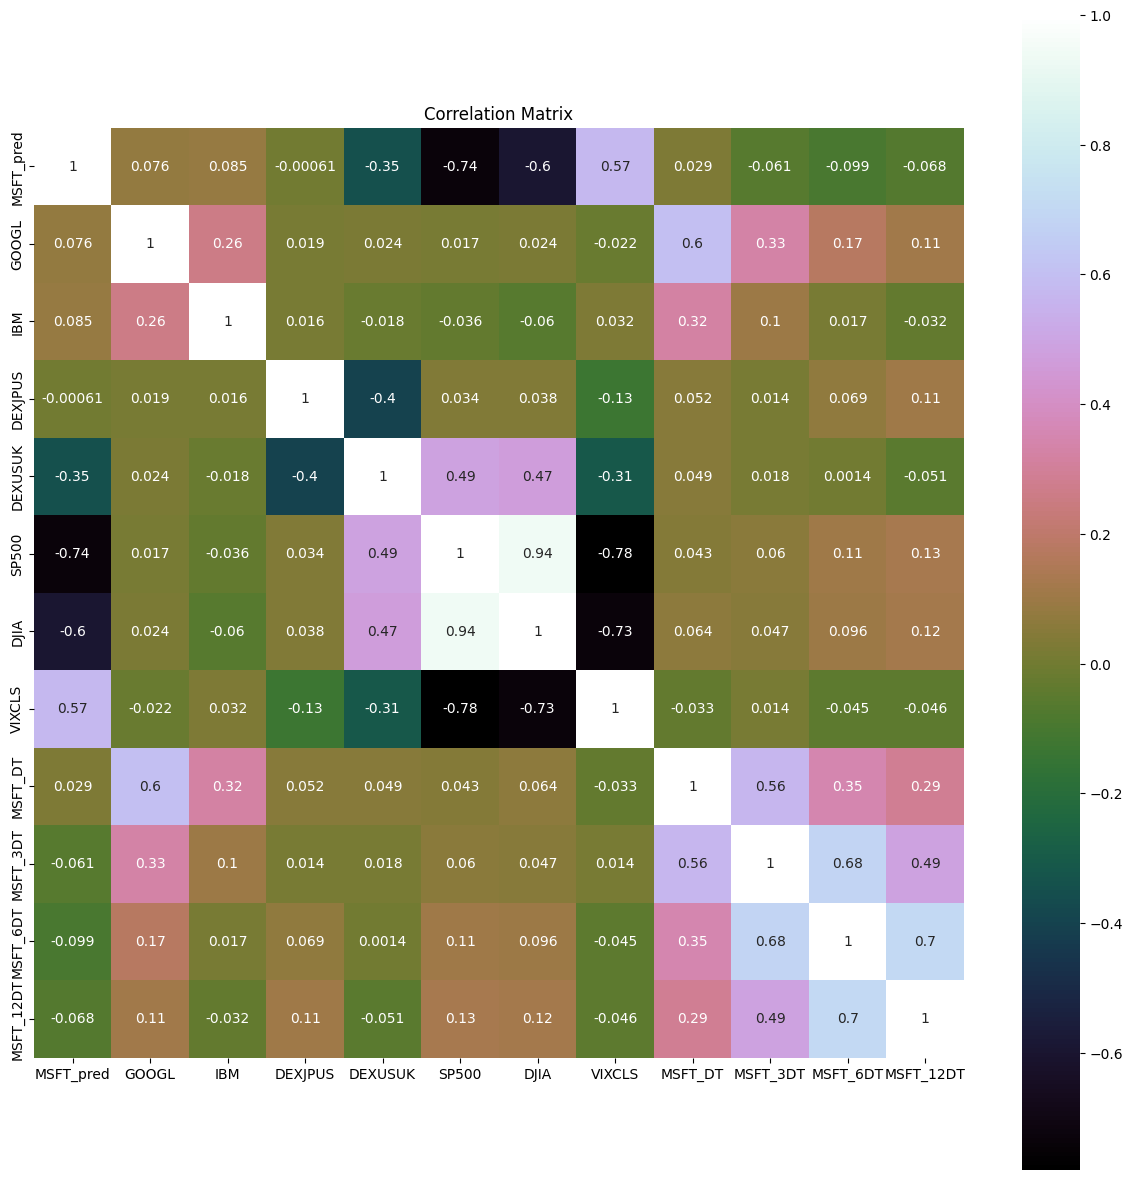

In [6]:
correlation = dataset.corr()
pyplot.figure(figsize = (15, 15))
pyplot.title('Correlation Matrix')
sns.heatmap(correlation, vmax=1, square=True, annot=True, cmap='cubehelix')

<Figure size 1500x1500 with 0 Axes>

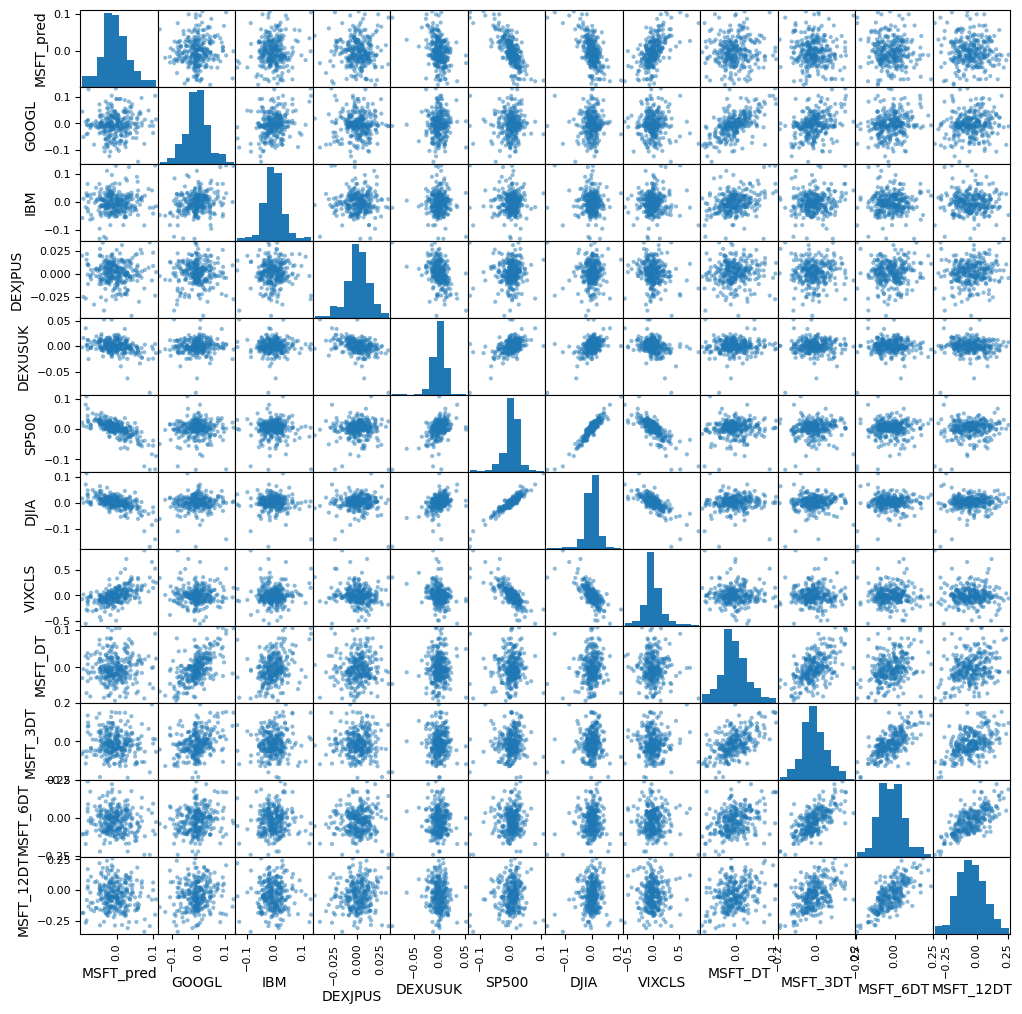

In [7]:
pyplot.figure(figsize=(15, 15))
scatter_matrix(dataset, figsize=(12, 12))
pyplot.show()

# **시계열 분석**

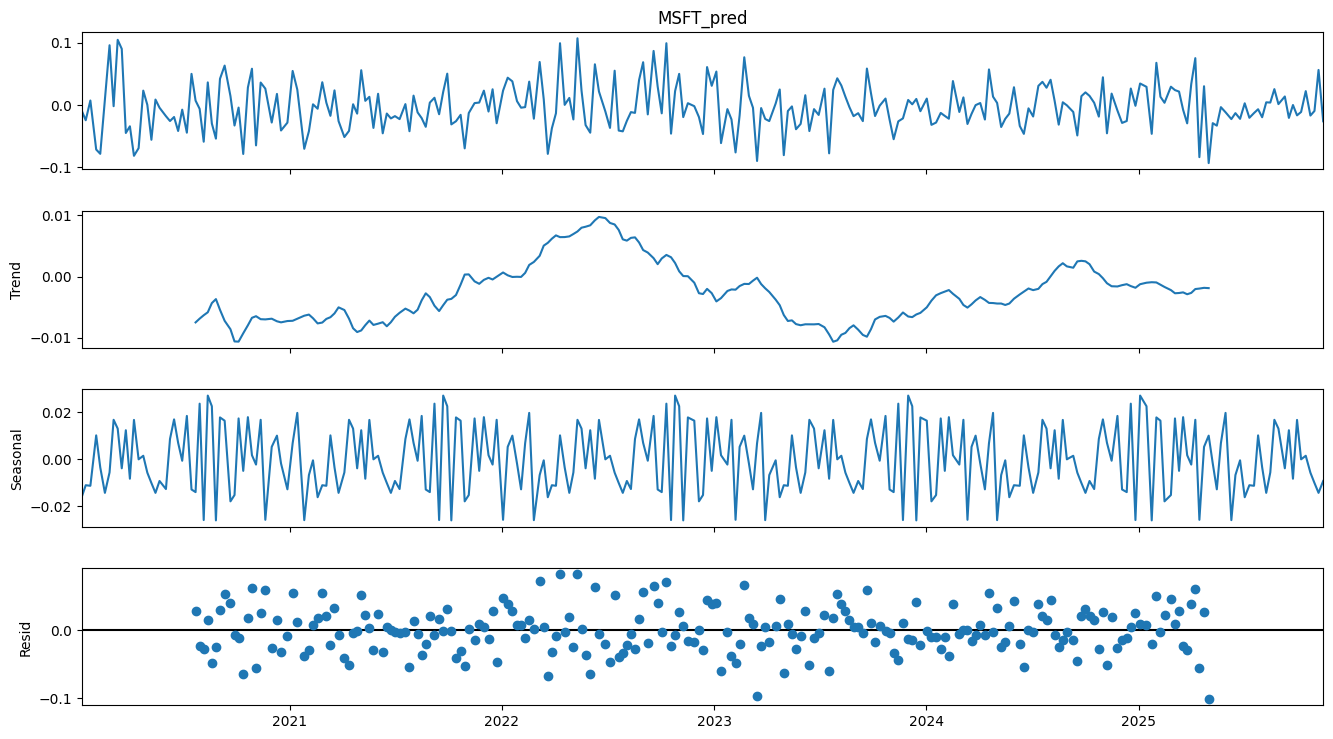

In [8]:
res = sm.tsa.seasonal_decompose(Y, period=52)
fig = res.plot()
fig.set_figheight(8)
fig.set_figwidth(15)
pyplot.show()

# **4. 모델 평가**

## 4-1. 훈련 - 테스트 데이터 분할 및 평가 메트릭

In [9]:
validation_size = 0.2
train_size = int(len(X)*(1-validation_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(X)]

## 4-2. 테스트 옵션 및 평가 메트릭

In [10]:
num_folds = 10
scoring = 'neg_mean_squared_error'

## 4-3. 모델 및 알고리즘 비교

### 4-3-1. 사이킷런을 이용한 머신러닝 모델

**회귀와 트리 회귀 알고리즘**

In [11]:
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))

**신경망 알고리즘**

In [12]:
models.append(('MLP', MLPRegressor()))

**앙상블 모델**

In [13]:
# 부스팅 방법
models.append(('ABR', AdaBoostRegressor()))
models.append(('GBR', GradientBoostingRegressor()))

# 배깅 방법
models.append(('RFR', RandomForestRegressor()))
models.append(('ETR', ExtraTreesRegressor()))

**교차 검증**

In [14]:
seed = 7
names = []
kfold_results = []
test_results = []
train_results = []
for name, model in models:
    names.append(name) ## k-겹 분석
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)

    # 평균 제곱 오차를 양수로 변환함. 낮을 수록 좋음.
    cv_results = -1*cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    kfold_results.append(cv_results)
    # 총 훈련기간
    res = model.fit(X_train, Y_train)
    train_result = mean_squared_error(res.predict(X_train), Y_train)
    train_results.append(train_result)
    # 테스트 결과
    test_result = mean_squared_error(res.predict(X_test), Y_test)
    test_results.append(test_result)

**교차 검증 결과**

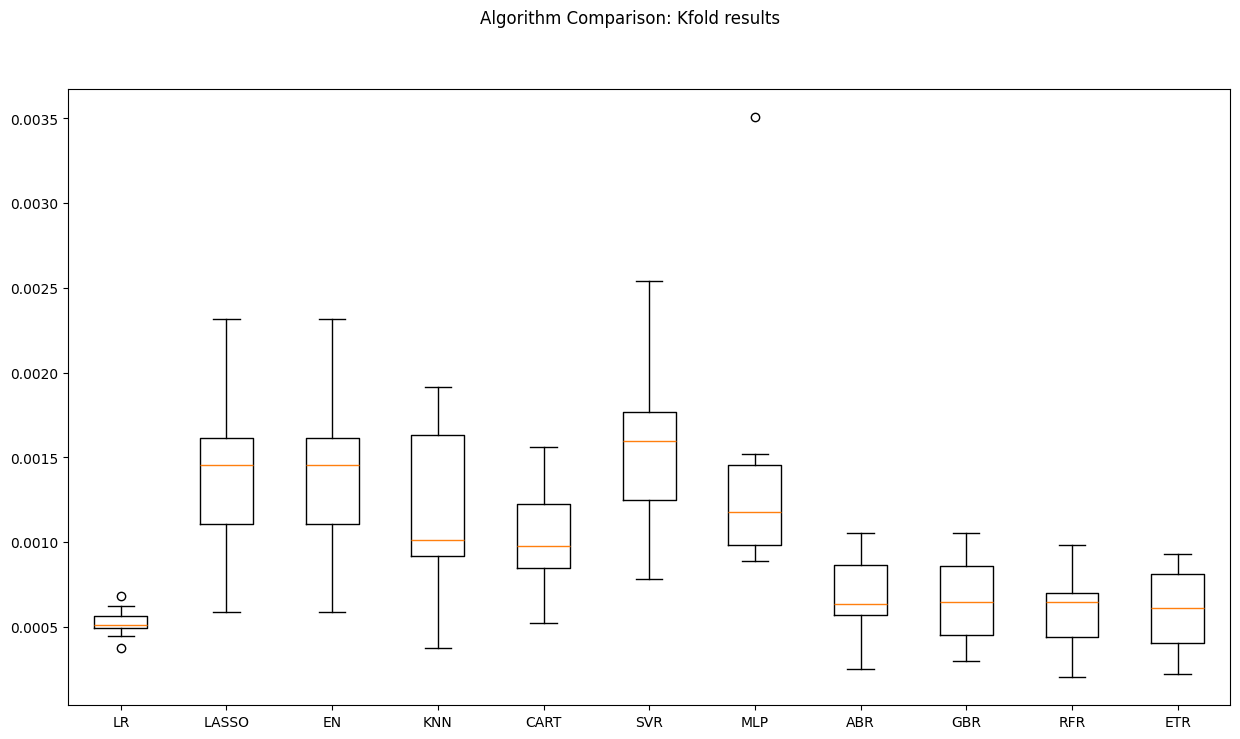

In [15]:
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison: Kfold results')
ax = fig.add_subplot(111)
pyplot.boxplot(kfold_results)
ax.set_xticklabels(names)
fig.set_size_inches(15, 8)
pyplot.show()

**훈련 및 테스트 오차**

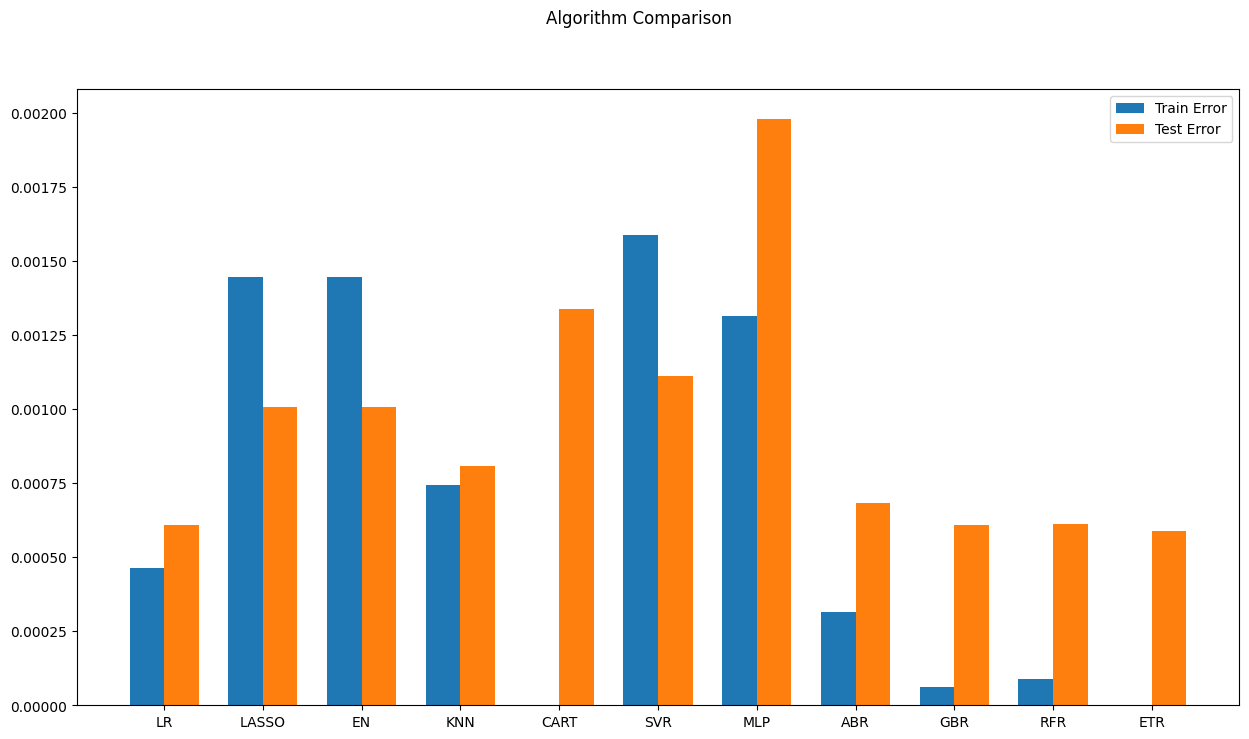

In [16]:
# 알고리즘 비교
fig = pyplot.figure()
ind = np.arange(len(names)) # 그룹의 x 위치
width = 0.35 # 막대 폭
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width/2, train_results, width = width, label = 'Train Error')
pyplot.bar(ind + width/2, test_results, width=width, label='Test Error')
fig.set_size_inches(15, 8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

## 4-3-2. 시계열 기반 모델: ARIMA 및 LSTM

**데이터셋 준비**

In [17]:
X_train_ARIMA = X_train.loc[:, ['GOOGL', 'IBM', 'DEXJPUS', 'SP500', 'DJIA', 'VIXCLS']]
X_test_ARIMA = X_test.loc[:, ['GOOGL', 'IBM', 'DEXJPUS', 'SP500', 'DJIA', 'VIXCLS']]
tr_len = len(X_train_ARIMA)
te_len = len(X_test_ARIMA)
to_len = len(X)

**(1, 0, 0) ARIMA 모델 설정**

In [18]:
modelARIMA = ARIMA(endog=Y_train, exog=X_train_ARIMA, order=[1, 0, 0])
model_fit = modelARIMA.fit()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


**ARIMA 모델 적합화**

In [19]:
error_Training_ARIMA = mean_squared_error(Y_train, model_fit.fittedvalues)
predicted = model_fit.predict(start= tr_len - 1, end = to_len - 1, exog = X_test_ARIMA)[1:]
error_Test_ARIMA = mean_squared_error(Y_test, predicted)
error_Test_ARIMA

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


0.0006094783027180824

**LSTM 모델을 위한 데이터셋 준비**

In [20]:
seq_len = 2

Y_train_LSTM = np.array(Y_train)[seq_len - 1:]
Y_test_LSTM  = np.array(Y_test)[seq_len - 1:]

X_train_LSTM = np.zeros((X_train.shape[0] + 1 - seq_len, seq_len, X_train.shape[1]))
X_test_LSTM  = np.zeros((X_test.shape[0] + 1 - seq_len, seq_len, X_test.shape[1]))

for i in range(seq_len):
    X_train_LSTM[:, i, :] = np.array(X_train)[
        i : X_train.shape[0] + i + 1 - seq_len, :
    ]
    X_test_LSTM[:, i, :] = np.array(X_test)[
        i : X_test.shape[0] + i + 1 - seq_len, :
    ]


**LSTM 구조 생성**

In [21]:
# LSTM 망 
def create_LSTMmodel(learn_rate = 0.01, momentum = 0): 
    # 모델 생성 
    model = Sequential()
    model.add(LSTM(50, input_shape=(X_train_LSTM.shape[1], X_train_LSTM.shape[2]))) 
    # 필요시 더 많은 셀 추가 
    model.add(Dense(1))
    optimizer = SGD(learning_rate=learn_rate, momentum=float(momentum))
    model.compile(loss='mse', optimizer='adam')
    return model
LSTMModel = create_LSTMmodel(learn_rate=0.01, momentum=0)
LSTMModel_fit = LSTMModel.fit(X_train_LSTM, Y_train_LSTM, validation_data = (X_test_LSTM, Y_test_LSTM), epochs = 330, batch_size=72, verbose = 0, shuffle = False)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**LSTM 적합화**

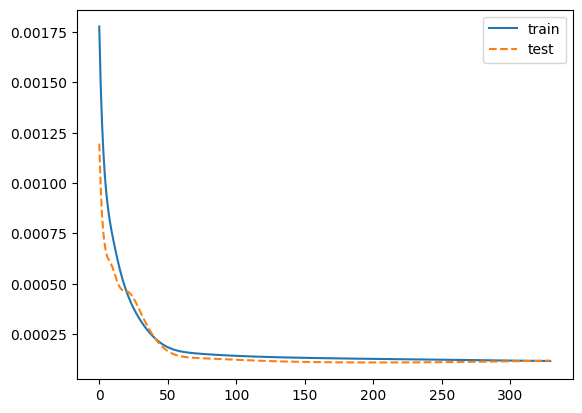

In [22]:
pyplot.plot(LSTMModel_fit.history['loss'], label='train',)
pyplot.plot(LSTMModel_fit.history['val_loss'], '--', label='test',)
pyplot.legend()
pyplot.show()

In [32]:
error_Training_LSTM = mean_squared_error(Y_train_LSTM, LSTMModel.predict(X_train_LSTM))
predicted = LSTMModel.predict(X_test_LSTM)
error_Test_LSTM = mean_squared_error(Y_test[1:], predicted)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


**시계열 모델과 딥러닝 모델 비교**

In [33]:
test_results.append(error_Test_ARIMA)
test_results.append(error_Test_LSTM)
train_results.append(error_Training_ARIMA)
train_results.append(error_Training_LSTM)
names.append("ARIMA")
names.append("LSTM")

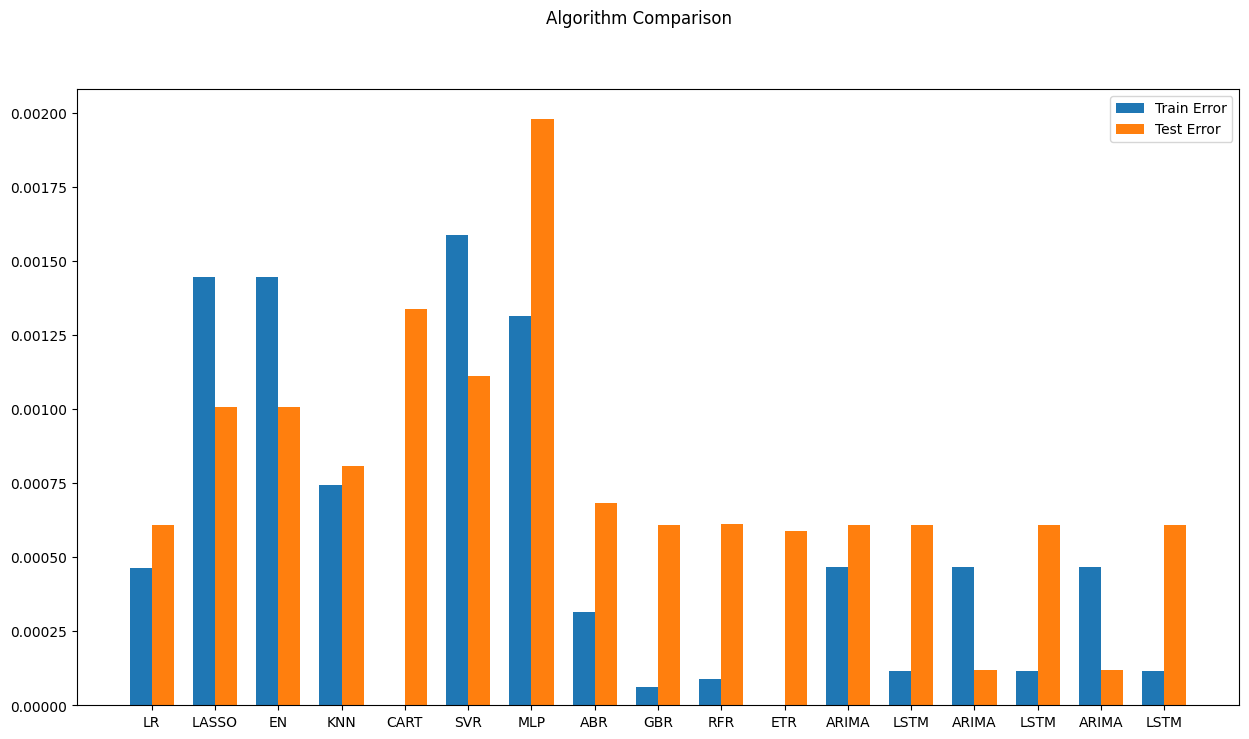

In [36]:
n = len(names)

ind = np.arange(n)
width = 0.35

fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)

pyplot.bar(ind - width/2, train_results[:n], width=width, label='Train Error')
pyplot.bar(ind + width/2, test_results[:n],  width=width, label='Test Error')

ax.set_xticks(ind)
ax.set_xticklabels(names)
fig.set_size_inches(15, 8)
pyplot.legend()
pyplot.show()


**ARIMA 모델 튜닝**

In [37]:
def evaluate_arima_model(arima_order):
    predicted = list()
    modelARIMA = ARIMA(endog = Y_train, exog = X_train_ARIMA, order = arima_order)
    model_fit = modelARIMA.fit()
    error = mean_squared_error(Y_train, model_fit.fittedvalues)
    return error

# ARIMA 모델에 대한 p, d, q 값 조합 평가
def evaluate_models(p_values, d_values, q_values):
    best_score, best_cfg = float("inf"), None
    for p in p_values:
        for d in d_values:
            for q in q_values:
                order = (p, d, q)
                try:
                    mse = evaluate_arima_model(order)
                    if mse < best_score:
                        best_score, best_cfg = mse, order
                    print('ARIMA%s MSE=%.7f' % (order, mse))
                except: 
                    continue
    print('Best ARIMA%s MSE=%.7f' % (best_cfg, best_score))

# 매개변수 평가
p_values = [0, 1, 2]
d_values = range(0, 2)
q_values = range(0, 2)
import warnings
warnings.filterwarnings("ignore")
evaluate_models(p_values, d_values, q_values)

ARIMA(0, 0, 0) MSE=0.0004707
ARIMA(0, 0, 1) MSE=0.0004654
ARIMA(0, 1, 0) MSE=0.0010074
ARIMA(0, 1, 1) MSE=0.0004887
ARIMA(1, 0, 0) MSE=0.0004674
ARIMA(1, 0, 1) MSE=0.0004615
ARIMA(1, 1, 0) MSE=0.0008096
ARIMA(1, 1, 1) MSE=0.0004938
ARIMA(2, 0, 0) MSE=0.0004475
ARIMA(2, 0, 1) MSE=0.0004430
ARIMA(2, 1, 0) MSE=0.0006071
ARIMA(2, 1, 1) MSE=0.0004660
Best ARIMA(2, 0, 1) MSE=0.0004430


# **모델 확정**

## 테스트셋에 대한 결과

In [38]:
# 모델 준비
modelARIMA_tuned = ARIMA(endog=Y_train, exog=X_train_ARIMA, order=[2, 0, 1])
model_fit_tuned = modelARIMA_tuned.fit()

# 검증셋에 대한 정확도 추정
predicted_tuned = model_fit.predict(start= tr_len - 1, end = to_len - 1, exog = X_test_ARIMA)[1:]
print(mean_squared_error(Y_test, predicted_tuned))

0.0006094783027180824


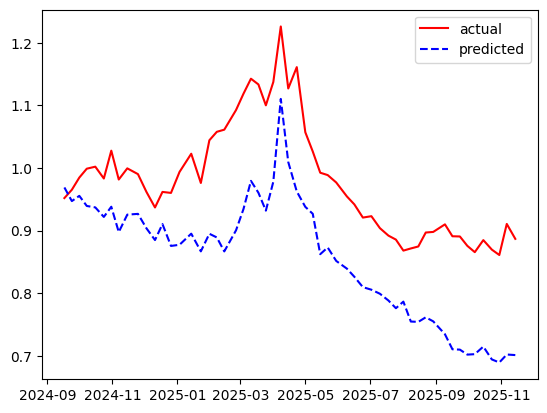

In [39]:
# 실제 데이터와 예측 데이터 그래프
predicted_tuned.index = Y_test.index
pyplot.plot(np.exp(Y_test).cumprod(), 'r', label = 'actual', )

# t와 a 분리하여 그리기
pyplot.plot(np.exp(predicted_tuned).cumprod(), 'b--', label = 'predicted')
pyplot.legend()
pyplot.rcParams["figure.figsize"] = (8, 5)
pyplot.show()